# This program is used to run Complacency Effect on the state of PA 

In [1]:
# Import all the libraries
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import re
import numpy as np
from pprint import pprint
from sklearn.linear_model import LinearRegression
import numpy as np

In [2]:
file_path = (r"..\..\final_data\PA.csv")

PA_data = pd.read_csv(file_path)

In [3]:
PA_data['primary_total_votes'] = PA_data['dem_primary_total'] + PA_data['rep_primary_total']
PA_data['general_total_votes'] = PA_data['dem_general_total'] + PA_data['rep_general_total']

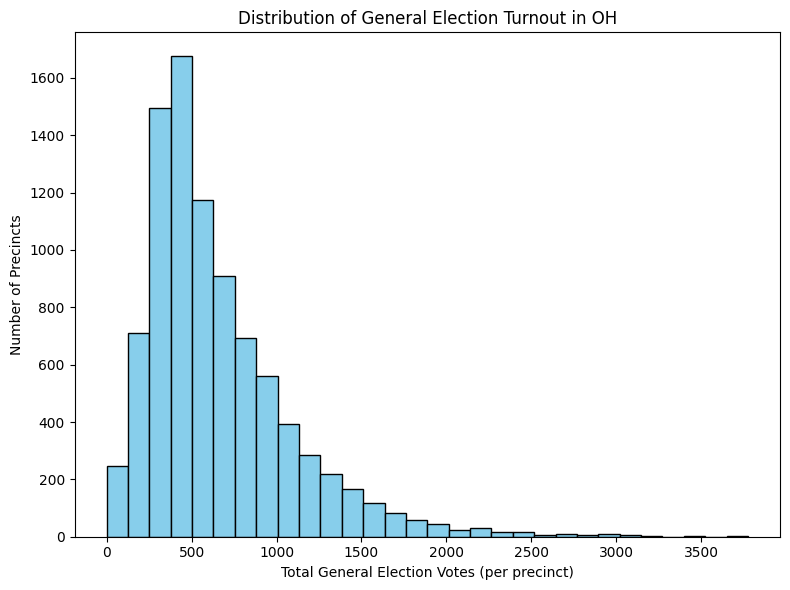

In [4]:
#Distribution of total general votes (Dem + Rep) per precinct

plt.figure(figsize=(8, 6))
plt.hist(PA_data['general_total_votes'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Total General Election Votes (per precinct)')
plt.ylabel('Number of Precincts')
plt.title('Distribution of General Election Turnout in OH')
plt.tight_layout()

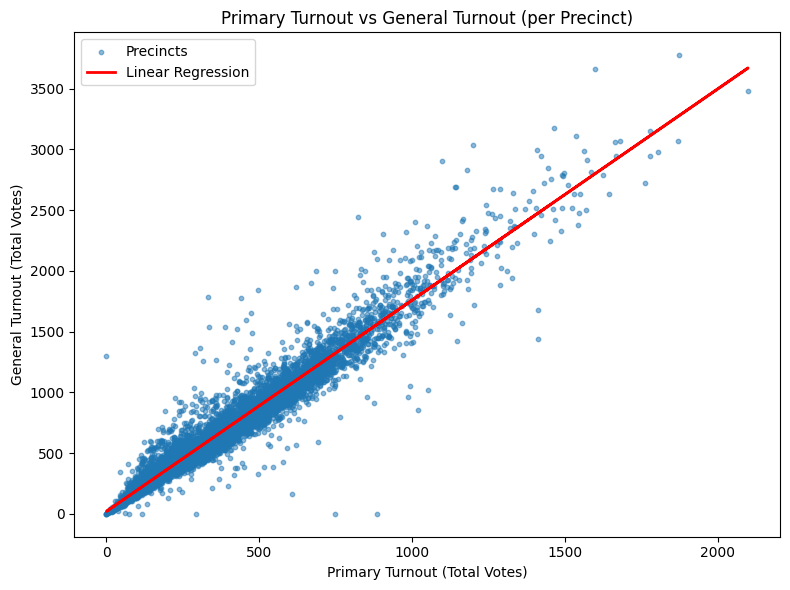

In [5]:
# Prepare X and y for regression
X = PA_data['primary_total_votes'].values.reshape(-1, 1)
y = PA_data['general_total_votes'].values

# Fit linear regression
reg = LinearRegression()
reg.fit(X, y)

# Predict values for the regression line
y_pred = reg.predict(X)

# Plot: Primary turnout vs General turnout with regression line
plt.figure(figsize=(8, 6))
plt.scatter(PA_data['primary_total_votes'], PA_data['general_total_votes'], alpha=0.5, s=10, label='Precincts')
plt.plot(PA_data['primary_total_votes'], y_pred, color='red', linewidth=2, label='Linear Regression')
plt.xlabel('Primary Turnout (Total Votes)')
plt.ylabel('General Turnout (Total Votes)')
plt.title('Primary Turnout vs General Turnout (per Precinct)')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# After fitting the model
beta_0 = reg.intercept_
beta_1 = reg.coef_[0]

print(f"Intercept (β₀): {beta_0:.4f}")
print(f"Slope (β₁): {beta_1:.4f}")

Intercept (β₀): 20.2958
Slope (β₁): 1.7382


In [7]:
# Estimating the size of a precinct uniform precinct size
# PA_data['precinct_size'] = ((PA_data['dem_general_total'] + PA_data['rep_general_total']))/0.75

# Estimate precinct size based geometric approach
# Calculate probability of voting for each party in the general election
PA_data["general_turnout"] = PA_data["rep_general_total"] + PA_data["dem_general_total"]
PA_data["primary_turnout"] = PA_data["rep_primary_total"] + PA_data["dem_primary_total"]
general_turnoutprob = 0.71 # General turnout prob for Rep
primary_turnoutprob= 0.42 # Primary turnout prob for Rep
m = general_turnoutprob / primary_turnoutprob
PA_data["general_turnout_est"] = (PA_data['primary_turnout'] + m * PA_data['general_turnout']) / (1 + m **2)
PA_data["precinct_size"] = PA_data["general_turnout_est"] / primary_turnoutprob 

In [8]:
# Calculate the margin of each precinct margin = abs(rep_primary_total - dem_primary_total) / (rep_primary_total + dem_primary_total)
PA_data['primary_margin'] = np.abs(PA_data['rep_primary_total'] - PA_data['dem_primary_total']) / (PA_data['rep_primary_total'] + PA_data['dem_primary_total'])


In [9]:
# Calculate estimated number of Democratic voters per precinct
PA_data['dem_voters'] = (PA_data['dem_primary_total'] / (PA_data['dem_primary_total'] + PA_data['rep_primary_total'])) * PA_data['precinct_size']
PA_data['rep_voters'] = (PA_data['rep_primary_total'] / (PA_data['dem_primary_total'] + PA_data['rep_primary_total'])) * PA_data['precinct_size']

In [11]:
# Determine the winner based on primary totals
PA_data['primary_winner'] = np.where(
    PA_data['rep_primary_total'] > PA_data['dem_primary_total'], 'rep', 'dem'
)  

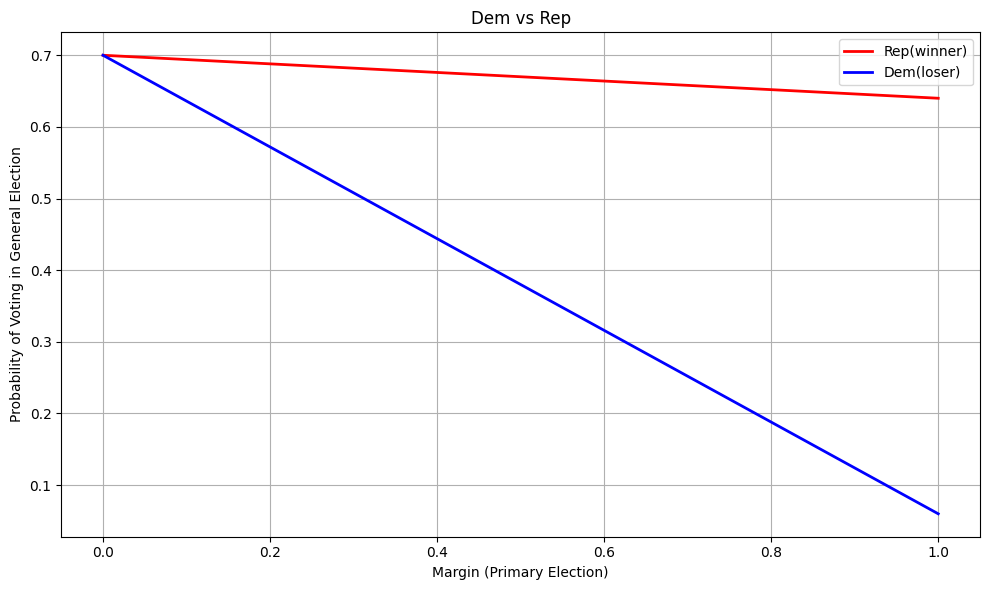

In [12]:
# Plotting vote chance
# Define x range: margin from 0 (tie) to 1 (blowout)
margins = np.linspace(0, 1, 200)

# Parameters
b = 0.7          # max vote probability at tie
m_w = 0.06      # steeper slope for winner
m_l = 0.64        # flatter slope for loser

# Calculate probabilities
prob_winner = b - m_w * margins
prob_loser = b - m_l * margins

# Plot
plt.figure(figsize=(10, 6))
plt.plot(margins, prob_winner, label="Rep(winner)", color='red', linewidth=2)
plt.plot(margins, prob_loser, label="Dem(loser)", color='blue', linewidth=2)

# Labels and titles
plt.title("Dem vs Rep")
plt.xlabel("Margin (Primary Election)")
plt.ylabel("Probability of Voting in General Election")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
# 1. Estimate number of non-primary voters for each party
PA_data['predicted_dem_gen'] = np.where(
    PA_data['primary_winner'] == 'dem',
    (b - PA_data['primary_margin'] * m_w)* PA_data['dem_voters'],  
    (b - PA_data['primary_margin'] * m_l)* PA_data['dem_voters']
)

# For Republicans
PA_data['predicted_rep_gen'] = np.where(
    PA_data['primary_winner'] == 'rep',
    (b - PA_data['primary_margin'] * m_w)* PA_data['rep_voters'],  
    (b - PA_data['primary_margin'] * m_l)* PA_data['rep_voters']
)

In [16]:
# Compare to actual general vote shares
PA_data['actual_general_rep_share'] = PA_data['rep_general_total'] / (
    PA_data['rep_general_total'] + PA_data['dem_general_total']
)
PA_data['predicted_rep_share'] = PA_data['predicted_rep_gen'] / (
    PA_data['predicted_rep_gen'] + PA_data['predicted_dem_gen']
)
PA_data['primary_rep_voteshare'] = PA_data['rep_primary_total'] / (
    PA_data['rep_primary_total'] + PA_data['dem_primary_total']
)

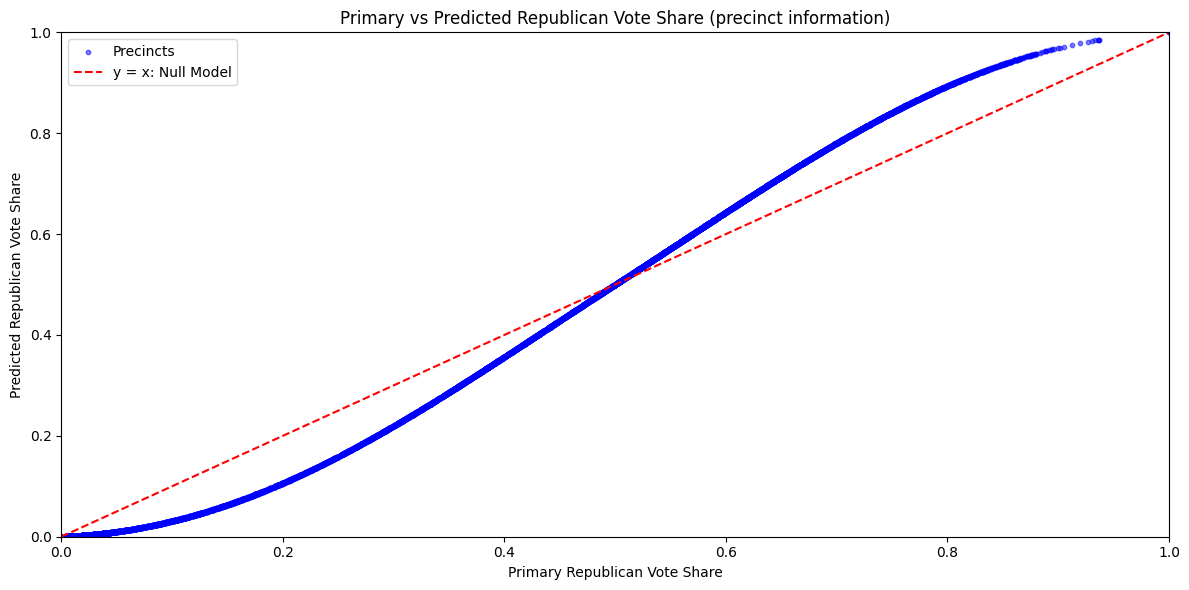

In [18]:
plt.figure(figsize=(12, 6))
plt.scatter(
    x=PA_data['primary_rep_voteshare'], 
    y=PA_data['predicted_rep_share'], 
    color='blue', label='Precincts', alpha=0.5, s=10
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x: Null Model')
plt.title('Primary vs Predicted Republican Vote Share (precinct information)')
plt.xlabel('Primary Republican Vote Share')
plt.ylabel('Predicted Republican Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


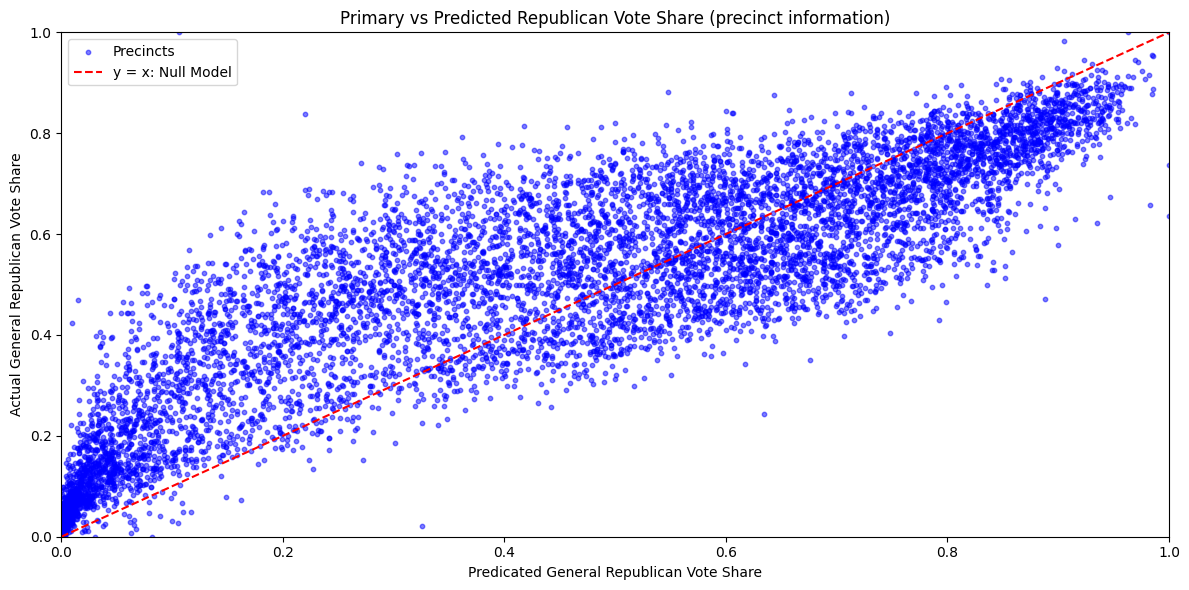

In [19]:
plt.figure(figsize=(12, 6))
plt.scatter(
    x=PA_data['predicted_rep_share'], 
    y=PA_data['actual_general_rep_share'], 
    color='blue', label='Precincts', alpha=0.5, s=10
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x: Null Model')
plt.title('Primary vs Predicted Republican Vote Share (precinct information)')
plt.xlabel('Predicated General Republican Vote Share')
plt.ylabel('Actual General Republican Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## State - level Information

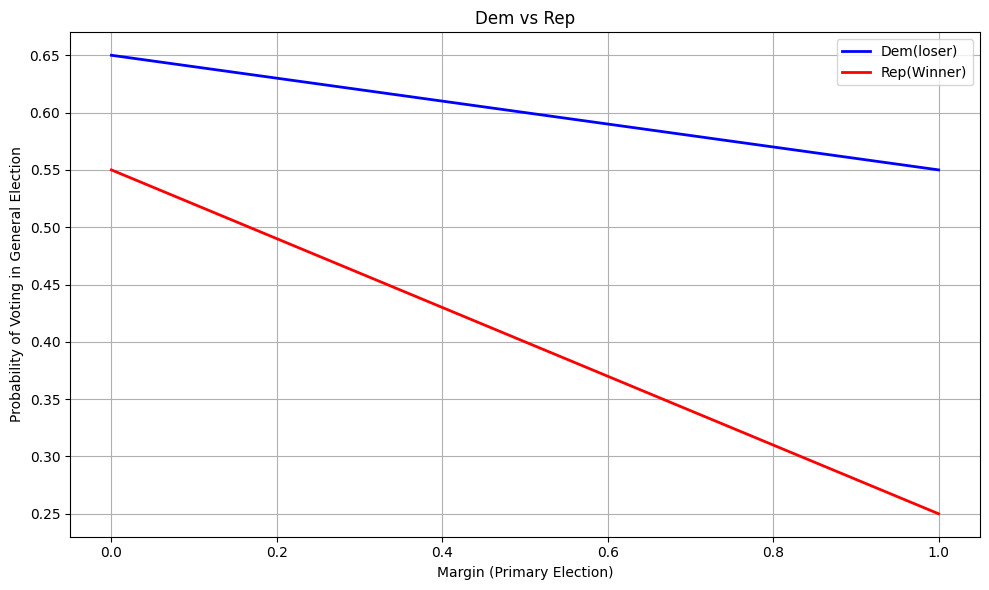

In [20]:
# Plotting vote chance
# Define x range: margin from 0 (tie) to 1 (blowout)
margins = np.linspace(0, 1, 200)

# Parameters
b_w = 0.55          # max vote probability at tie
b_l = 0.65
m_w = 0.3      # steeper slope for winner
m_l = 0.1        # flatter slope for loser

# Calculate probabilities
prob_winner = b_w - m_w * margins
prob_loser = b_l - m_l * margins

# Plot
plt.figure(figsize=(10, 6))
plt.plot(margins, prob_loser, label="Dem(loser)", color='blue', linewidth=2)
plt.plot(margins, prob_winner, label="Rep(Winner)", color='red', linewidth=2)

# Labels and titles
plt.title("Dem vs Rep")
plt.xlabel("Margin (Primary Election)")
plt.ylabel("Probability of Voting in General Election")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
# Determine the winner based on primary totals
# PA_data['state_primary_winner'] = np.where(
#     PA_data['rep_primary_total'].sum() > PA_data['dem_primary_total'].sum(), 'rep', 'dem'
# )  
PA_data['state_primary_winner'] = np.where(
    PA_data['rep_primary_total'].sum() > PA_data['dem_primary_total'].sum(), 'rep', 'dem'
)  

In [23]:
# 1. Estimate number of non-primary voters for each party
PA_data['predicted_dem_gen_state'] = np.where(
    PA_data['state_primary_winner'] == 'dem',
    (b_w - PA_data['primary_margin'] * m_w)* PA_data['dem_voters'],  
    (b_l - PA_data['primary_margin'] * m_l)* PA_data['dem_voters']
)

# For Republicans
PA_data['predicted_rep_gen_state'] = np.where(
    PA_data['state_primary_winner'] == 'rep',
    (b_w - PA_data['primary_margin'] * m_w)* PA_data['rep_voters'],  
    (b_l - PA_data['primary_margin'] * m_l)* PA_data['rep_voters']
)


In [24]:
# Compute predicted Republican vote share based on state primary winner
PA_data['predicted_rep_share_state'] = PA_data['predicted_rep_gen_state'] / (
    PA_data['predicted_rep_gen_state'] + PA_data['predicted_dem_gen_state']
)

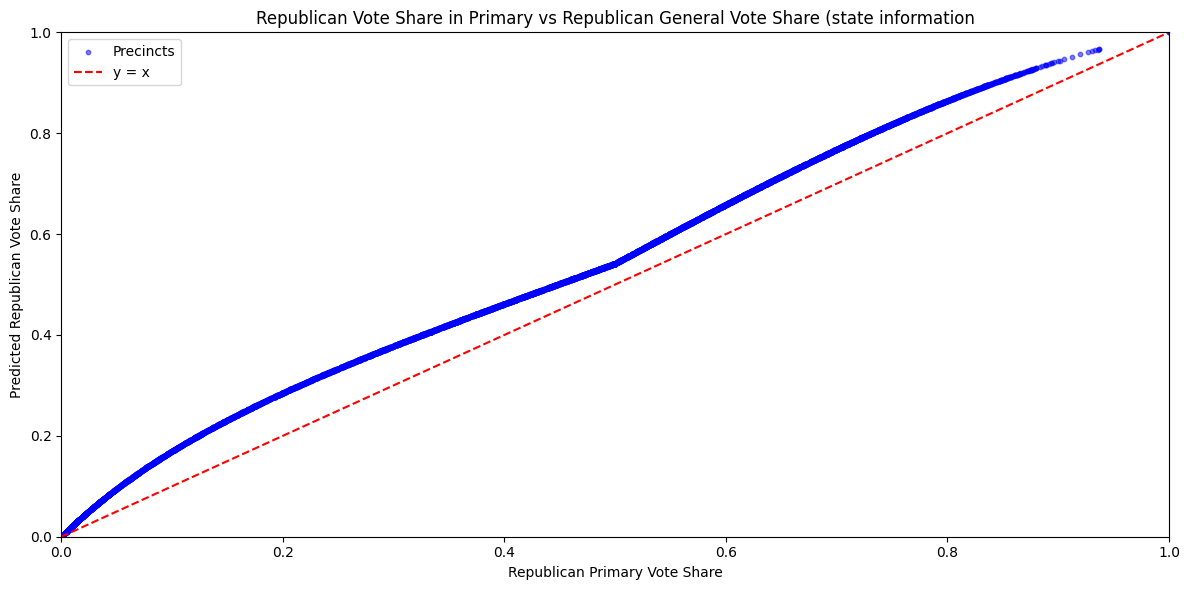

In [25]:
plt.figure(figsize=(12, 6))
plt.scatter(
    x=PA_data['primary_rep_voteshare'], 
    y=PA_data['predicted_rep_share_state'], 
    color='blue', label='Precincts', alpha=0.5, s=10
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x')
plt.title('Republican Vote Share in Primary vs Republican General Vote Share (state information')
plt.xlabel('Republican Primary Vote Share')
plt.ylabel('Predicted Republican Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


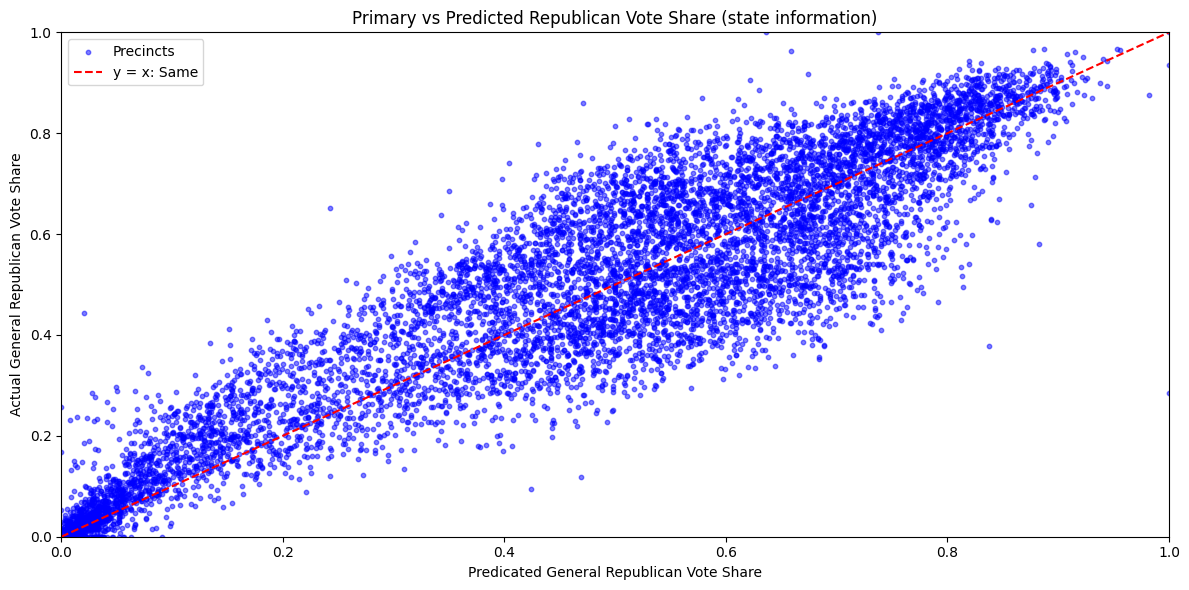

In [26]:
plt.figure(figsize=(12, 6))
plt.scatter(
    x=PA_data['actual_general_rep_share'], 
    y=PA_data['predicted_rep_share_state'], 
    color='blue', label='Precincts', alpha=0.5, s=10
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x: Same')
plt.title('Primary vs Predicted Republican Vote Share (state information)')
plt.xlabel('Predicated General Republican Vote Share')
plt.ylabel('Actual General Republican Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## Plotting these 2 effects

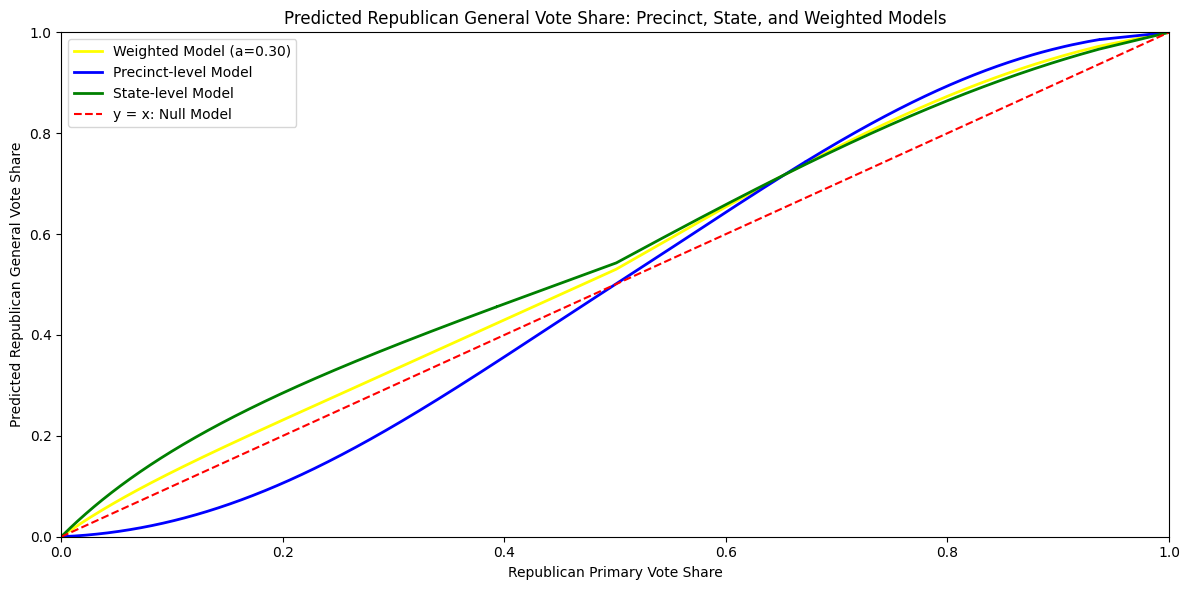

In [27]:
# Create a weighted model: a * precinct + (1 - a) * state
a = 0.3  

PA_data['predicted_rep_share_weighted'] = (
    a * PA_data['predicted_rep_share'] +
    (1 - a) * PA_data['predicted_rep_share_state']
)

# Sort for smooth plotting
sorted_weighted = PA_data.sort_values('primary_rep_voteshare')

plt.figure(figsize=(12, 6))
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_weighted'],
    color='yellow', linewidth=2, label=f'Weighted Model (a={a:.2f})'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share'],
    color='blue', linewidth=2, label='Precinct-level Model'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_state'],
    color='green', linewidth=2, label='State-level Model'
)

plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x: Null Model')
plt.title('Predicted Republican General Vote Share: Precinct, State, and Weighted Models')
plt.xlabel('Republican Primary Vote Share')
plt.ylabel('Predicted Republican General Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

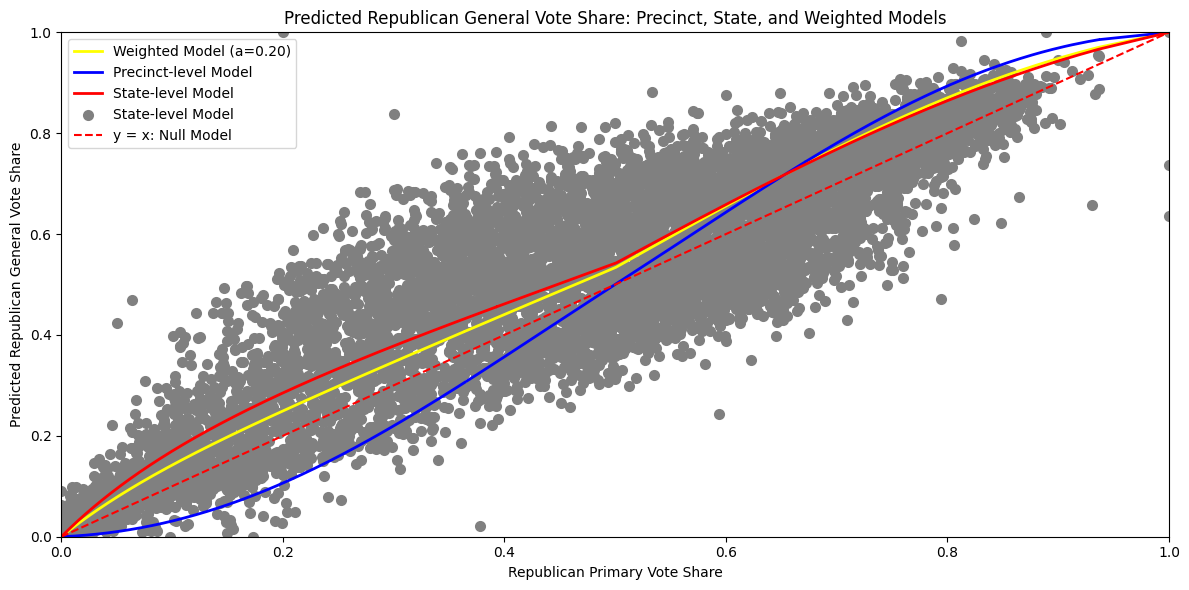

In [28]:
# Create a weighted model: a * precinct + (1 - a) * state
a = 0.2  

PA_data['predicted_rep_share_weighted'] = (
    a * PA_data['predicted_rep_share'] +
    (1 - a) * PA_data['predicted_rep_share_state']
)

# Sort for smooth plotting
sorted_weighted = PA_data.sort_values('primary_rep_voteshare')

plt.figure(figsize=(12, 6))
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_weighted'],
    color='yellow', linewidth=2, label=f'Weighted Model (a={a:.2f})'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share'],
    color='blue', linewidth=2, label='Precinct-level Model'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_state'],
    color='red', linewidth=2, label='State-level Model'
)
plt.scatter(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['actual_general_rep_share'],
    color='gray', linewidth=2, label='State-level Model'
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x: Null Model')
plt.title('Predicted Republican General Vote Share: Precinct, State, and Weighted Models')
plt.xlabel('Republican Primary Vote Share')
plt.ylabel('Predicted Republican General Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

(0.0, 1.0)

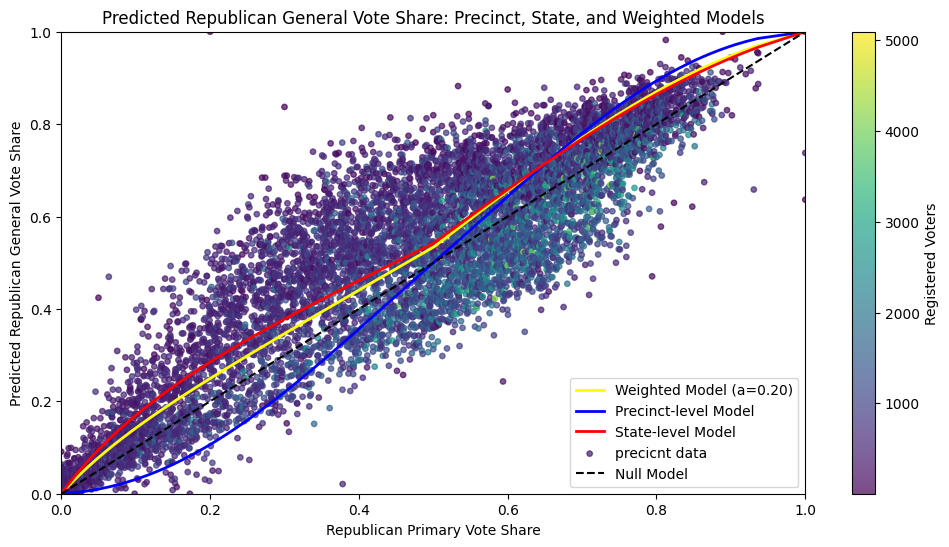

In [29]:
# Create a weighted model: a * precinct + (1 - a) * state
a = 0.2  

PA_data['predicted_rep_share_weighted'] = (
    a * PA_data['predicted_rep_share'] +
    (1 - a) * PA_data['predicted_rep_share_state']
)

# Sort for smooth plotting
sorted_weighted = PA_data.sort_values('primary_rep_voteshare')

plt.figure(figsize=(12, 6))
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_weighted'],
    color='yellow', linewidth=2, label=f'Weighted Model (a={a:.2f})'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share'],
    color='blue', linewidth=2, label='Precinct-level Model'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_state'],
    color='red', linewidth=2, label='State-level Model'
)

# Scatter actual values, color by precinct_size
sc = plt.scatter(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['actual_general_rep_share'],
    c=sorted_weighted['precinct_size'],
    cmap='viridis',
    alpha=0.7,
    s=15,
    label='precicnt data'
)
plt.colorbar(sc, label='Registered Voters')

plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Null Model')
plt.title('Predicted Republican General Vote Share: Precinct, State, and Weighted Models')
plt.xlabel('Republican Primary Vote Share')
plt.ylabel('Predicted Republican General Vote Share')
plt.legend()
plt.xlim(0, 1)
plt.ylim(0, 1)